# 05 — Model 3: Medium 1D CNN

**Model 3** of the complexity ladder — the next rung up from Model 2:

> linear (~6) → **shallow CNN (3,858)** → **medium CNN (~44k)** → deep CNN (~404k) → transformer (~1–2M)

This is deliberately a **repeat of the proven Model 2 pattern**, so the narration is light. It is the
**same `CNN1D` architecture and the same `train_cnn` recipe** — only the config changes: Model 3 is
the **`[32, 64, 64]`** variant (**3 conv blocks, wider channels**) with **~11× Model 2's parameters**.
For what a 1D CNN is and how the pieces work, see notebook 04.

**The question this rung answers.** Model 3 has ~11× the parameters on the *same 80 training samples*.
Train/val will almost certainly pin near 1.0 — so the real question is the **overfitting watch**:
does **test** accuracy hold (or drop) as capacity grows? A larger model generalising *worse* would be
the overfitting-hurts-test signal we're tracking up the ladder.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.data.preprocessing import load_ecg200
from src.models.cnn import (
    build_cnn, count_parameters, train_cnn, torch_predict_proba, set_seed,
    SEED, LEARNING_RATE, BATCH_SIZE, WEIGHT_DECAY, PATIENCE, CNN_VARIANTS,
)
from src.evaluation.metrics import classification_metrics, format_metrics, overfitting_gap

FIG_DIR = PROJECT_ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

# Same cached ECG200 split as Models 1–2.
X_train, y_train = load_ecg200("train")
X_val,   y_val   = load_ecg200("val")
X_test,  y_test  = load_ecg200("test")
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")

train (80, 96)  val (20, 96)  test (100, 96)


## Architecture — same module, deeper/wider config

Model 3 is `CNN1D` with `conv_channels = [32, 64, 64]` (3 blocks) vs Model 2's `[16, 32]` (2 blocks).
Same block (Conv1d k=7 → BatchNorm → ReLU → MaxPool), same GAP + linear head, same everything else —
only the capacity changes. We seed **before** building (the determinism fix from Model 2: weight init
consumes RNG at build time, so `set_seed(SEED)` must precede `build_cnn` for order-independent results).

In [2]:
set_seed(SEED)                       # anchor init BEFORE building (order-independent)
model = build_cnn(variant="medium", n_classes=2, in_channels=1)
n_params = count_parameters(model)
print(f"Model 3 (medium) params: {n_params:,}")
print(f"ladder so far — shallow {count_parameters(build_cnn('shallow')):,} | "
      f"medium {n_params:,} (~{n_params/count_parameters(build_cnn('shallow')):.0f}x)")

Model 3 (medium) params: 43,682
ladder so far — shallow 3,858 | medium 43,682 (~11x)


## Training — identical recipe to Model 2

Same `train_cnn`: Adam (lr 1e-3, weight_decay 1e-4), batch 16, ≤200 epochs, early stopping
(patience 30) + best-val-loss checkpoint, class-weighted cross-entropy for the ~65/35 imbalance,
seed 42. Nothing about training changes — only the model's capacity — so any difference in results is
attributable to complexity, not a confounded training change.

In [3]:
result = train_cnn(model, X_train, y_train, X_val, y_val)   # recipe defaults; seed=42
print(f"best epoch = {result['best_epoch']} of {len(result['history']['train_loss'])} run  "
      f"(Adam lr={LEARNING_RATE}, batch={BATCH_SIZE}, wd={WEIGHT_DECAY}, patience={PATIENCE}, seed={SEED})")

best epoch = 169 of 199 run  (Adam lr=0.001, batch=16, wd=0.0001, patience=30, seed=42)


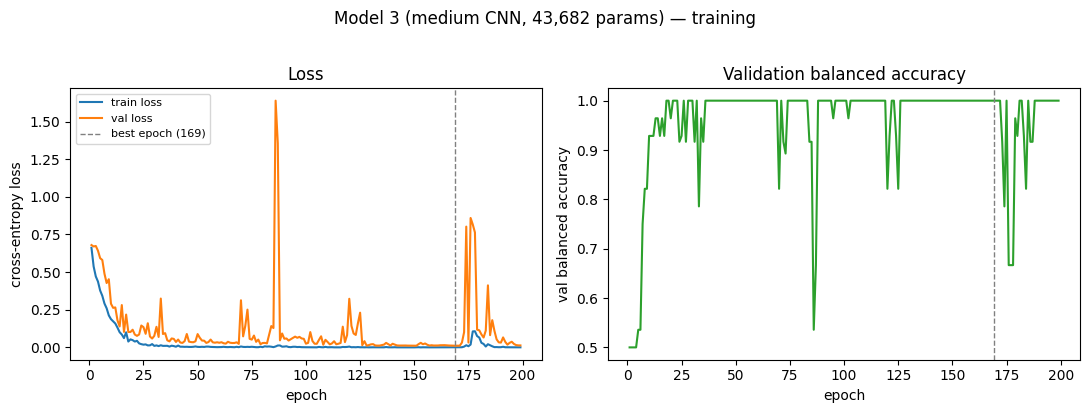

In [4]:
h = result["history"]; epochs = np.arange(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, h["train_loss"], label="train loss")
ax[0].plot(epochs, h["val_loss"], label="val loss")
ax[0].axvline(result["best_epoch"], color="grey", ls="--", lw=1, label=f"best epoch ({result['best_epoch']})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy loss"); ax[0].set_title("Loss"); ax[0].legend(fontsize=8)
ax[1].plot(epochs, h["val_balanced_accuracy"], color="C2")
ax[1].axvline(result["best_epoch"], color="grey", ls="--", lw=1)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val balanced accuracy"); ax[1].set_title("Validation balanced accuracy")
fig.suptitle(f"Model 3 (medium CNN, {n_params:,} params) — training", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_model3_training.png", dpi=150, bbox_inches="tight"); plt.show()

## Results, the accuracy gate, and the overfitting watch

In [5]:
predict_proba = torch_predict_proba(model)
splits = {}
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    prob = predict_proba(X); splits[name] = classification_metrics(y, prob.argmax(1), prob)
    print(f"{name:5s} {format_metrics(splits[name])}")

test_acc = splits["test"]["accuracy"]
gap_val = overfitting_gap(splits["val"]["accuracy"], test_acc)
gap_train = overfitting_gap(splits["train"]["accuracy"], test_acc)
MODEL2_TEST = 0.810
print(f"\noverfitting gap:  train-test = {gap_train:+.3f}   val-test = {gap_val:+.3f}   (Model 2 was +0.19)")
print(f">>> 80% GATE: {'PASS' if test_acc >= 0.80 else 'FAIL'}  (test accuracy {test_acc:.3f})")
if test_acc >= MODEL2_TEST:
    print(f">>> vs Model 2 ({MODEL2_TEST}): HELD/IMPROVED (+{test_acc-MODEL2_TEST:.3f}) — no overfitting-hurts-test signal at this rung")
else:
    print(f">>> vs Model 2 ({MODEL2_TEST}): DROPPED by {MODEL2_TEST-test_acc:.3f} — overfitting-hurts-test signal, FLAGGED")

train accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000
val   accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000
test  accuracy=0.880  balanced_accuracy=0.870  f1=0.906  roc_auc=0.941

overfitting gap:  train-test = +0.120   val-test = +0.120   (Model 2 was +0.19)
>>> 80% GATE: PASS  (test accuracy 0.880)
>>> vs Model 2 (0.81): HELD/IMPROVED (+0.070) — no overfitting-hurts-test signal at this rung


### What the results mean

**Model 3 (medium CNN, 43,682 parameters) reaches test accuracy ≈ 0.88** (balanced ≈ 0.87, F1 ≈ 0.91,
ROC-AUC ≈ 0.94) — **clears the 80% gate comfortably**, and notably **improves on Model 2's 0.81**
rather than degrading. Train and val are pinned at 1.00 (expected with 44k parameters on 80 samples),
but because **test rose**, the **overfitting gap actually shrank to +0.12** (from Model 2's +0.19).

So the overfitting-hurts-test signal we're watching for **did not appear at this rung**: the ~11×
capacity increase *helped* generalisation on ECG200 rather than hurting it. That is itself useful
information — the small dataset is not yet capacity-saturated at ~44k parameters. Whether the trend
turns (test dropping, gap widening) will be the key thing to watch at Model 4 (~404k) and the
transformer (~1–2M). Model 3 is a valid, well-behaved subject for the later faithfulness analysis.

## Summary

**Model 3 — medium 1D CNN, 43,682 parameters, test accuracy ≈ 0.88 (PASS, improved vs Model 2),
overfitting gap +0.12.** Same architecture and recipe as Model 2, wider/deeper. The next rung, Model 4
(deep CNN, ~404k), reuses this exact code with the `deep` config. See `DECISIONS_LOG.md`.

## 6. Attribution methods on Model 3 (inspection only — no scoring yet)

Same three methods as Model 2, reused unchanged (Model 3 exposes the same `predict_proba` contract):
**KernelSHAP** (grid-native, seeded — seed 0), **FeatureAblation** (grid-native, deterministic), and
**Integrated Gradients** (gradient-based; baseline = Zero PM, per-timestep values summed to regions via
completeness, model in eval mode for the BatchNorm gradient fix — see notebook 04 for the details).
We inspect the raw per-region attributions and run the **watch-threads** from Models 1–2; we do **not**
compute CMI here.

In [6]:
from src.xai.regions import build_region_grid, REGION_SIZE_PRIMARY_PCT
from src.xai.feature_ablation import feature_ablation
from src.xai.kernel_shap import kernel_shap
from src.xai.integrated_gradients import integrated_gradients

grid = build_region_grid(X_test.shape[1], REGION_SIZE_PRIMARY_PCT); n_reg = grid.n_regions
# `model` and `predict_proba` come from the training cells above (Model 3, trained).

FA = np.array([feature_ablation(predict_proba, s, grid, "zero") for s in X_test])
KS = np.array([kernel_shap(predict_proba, s, grid, "zero") for s in X_test])   # seed=0
IG = np.array([integrated_gradients(model, s, grid, "zero") for s in X_test])

# IG completeness re-check on Model 3
def ig_err(s):
    tc = int(predict_proba(s[None, :])[0].argmax())
    return abs(integrated_gradients(model, s, grid, "zero").sum()
               - (predict_proba(s[None, :])[0, tc] - predict_proba(np.zeros_like(s)[None, :])[0, tc]))
print(f"IG sanity: not all-zero = {not np.allclose(IG, 0)}, nonzero regions = {(np.abs(IG).sum(0) > 1e-9).sum()}/{n_reg}, "
      f"mean|completeness error|(20) = {np.mean([ig_err(s) for s in X_test[:20]]):.4f}")

def profile(A):
    m = np.abs(A).mean(0); return m / m.max()
prof = {"FeatureAblation": profile(FA), "KernelSHAP": profile(KS), "IntegratedGradients": profile(IG)}
for name, v in prof.items(): print(f"{name:20s}", np.round(v, 2))
c = lambda a, b: np.corrcoef(prof[a], prof[b])[0, 1]
print(f"\nagreement: FA-KS={c('FeatureAblation','KernelSHAP'):.2f}  "
      f"FA-IG={c('FeatureAblation','IntegratedGradients'):.2f}  "
      f"KS-IG={c('KernelSHAP','IntegratedGradients'):.2f}   (Model 2 was 0.98 / 0.87 / 0.88)")

# THREAD: region-0 recurrence
print("\nTHREAD region-0:")
for name, A in [("FeatureAblation", FA), ("KernelSHAP", KS), ("IntegratedGradients", IG)]:
    mean_abs = np.abs(A).mean(0)
    print(f"  {name:20s} top region = {int(mean_abs.argmax())}, region-0 share = {mean_abs[0]/mean_abs.sum():.2f}, "
          f"top-region-is-0 for {(np.argmax(np.abs(A),1)==0).sum()}/100 beats")

IG sanity: not all-zero = True, nonzero regions = 10/10, mean|completeness error|(20) = 0.0023
FeatureAblation      [1.   0.6  0.36 0.58 0.28 0.22 0.21 0.3  0.25 0.28]
KernelSHAP           [1.   0.41 0.42 0.75 0.42 0.43 0.36 0.51 0.23 0.23]
IntegratedGradients  [0.67 0.44 0.55 1.   0.38 0.32 0.33 0.59 0.31 0.19]

agreement: FA-KS=0.85  FA-IG=0.60  KS-IG=0.78   (Model 2 was 0.98 / 0.87 / 0.88)

THREAD region-0:
  FeatureAblation      top region = 0, region-0 share = 0.25, top-region-is-0 for 49/100 beats
  KernelSHAP           top region = 0, region-0 share = 0.21, top-region-is-0 for 56/100 beats
  IntegratedGradients  top region = 3, region-0 share = 0.14, top-region-is-0 for 22/100 beats


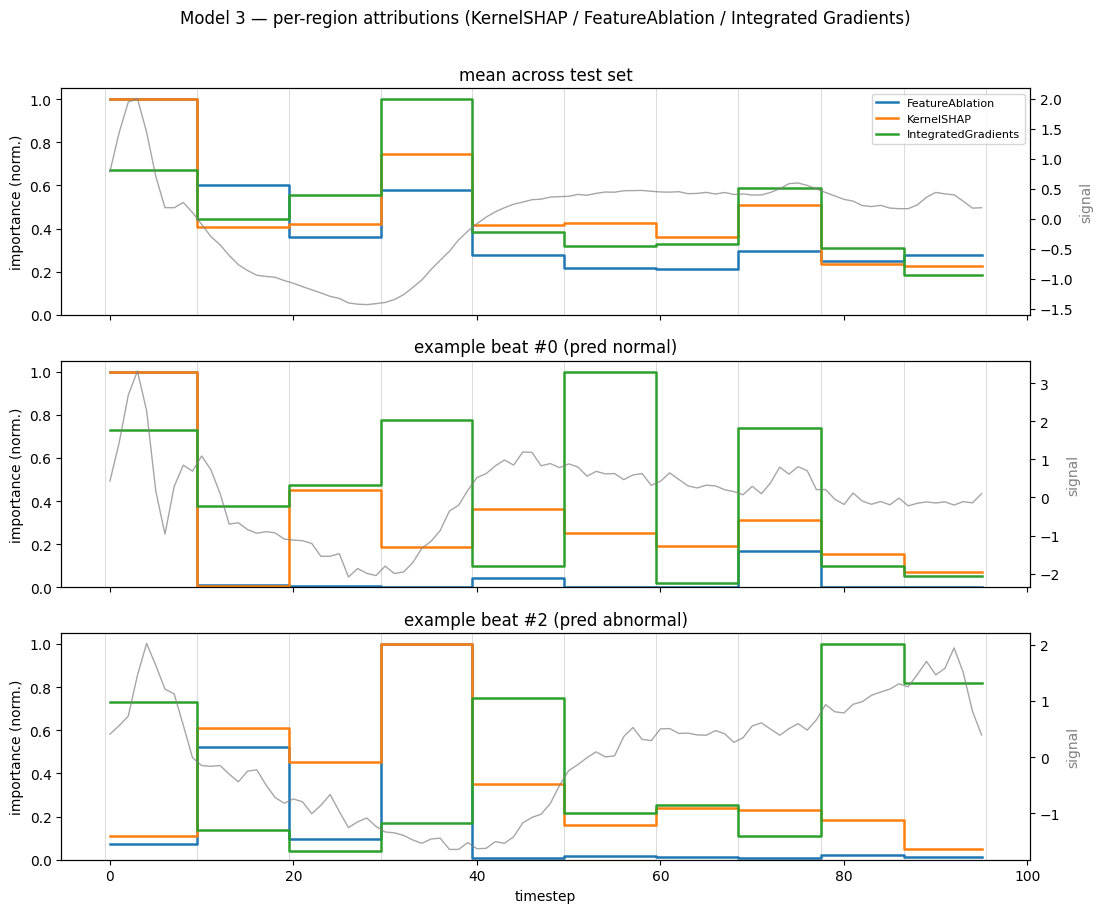

In [7]:
t = np.arange(X_test.shape[1]); to_steps = lambda pr: pr[grid.labels]
preds = predict_proba(X_test).argmax(1)
idx_norm, idx_abn = int(np.where(preds==1)[0][0]), int(np.where(preds==0)[0][0])
def norm(a): return np.abs(a)/np.abs(a).max()
rows = [("mean across test set", X_test.mean(0), prof),
        (f"example beat #{idx_norm} (pred normal)", X_test[idx_norm],
            {"FeatureAblation":norm(FA[idx_norm]),"KernelSHAP":norm(KS[idx_norm]),"IntegratedGradients":norm(IG[idx_norm])}),
        (f"example beat #{idx_abn} (pred abnormal)", X_test[idx_abn],
            {"FeatureAblation":norm(FA[idx_abn]),"KernelSHAP":norm(KS[idx_abn]),"IntegratedGradients":norm(IG[idx_abn])})]
colors = {"FeatureAblation":"C0","KernelSHAP":"C1","IntegratedGradients":"C2"}
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, (title, sig, profs) in zip(axes, rows):
    for b in np.append(grid.bounds[:,0], grid.bounds[-1,1]): ax.axvline(b-0.5, color="grey", lw=0.5, alpha=0.4)
    for name, pr in profs.items(): ax.plot(t, to_steps(pr), color=colors[name], lw=1.8, label=name, drawstyle="steps-mid")
    ax.set_ylabel("importance (norm.)"); ax.set_title(title); ax.set_ylim(0, 1.05)
    ax2 = ax.twinx(); ax2.plot(t, sig, color="0.5", lw=1, alpha=0.7); ax2.set_ylabel("signal", color="0.5")
axes[0].legend(loc="upper right", fontsize=8); axes[-1].set_xlabel("timestep")
fig.suptitle("Model 3 — per-region attributions (KernelSHAP / FeatureAblation / Integrated Gradients)", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_model3_attributions.png", dpi=150, bbox_inches="tight"); plt.show()

### What the attributions say (read against the Model 1–2 threads)

**IG is sane.** Completeness holds (~0.002 residual, the 50-step Riemann approximation) and it's
non-degenerate — a real attribution, safe to score later.

**Agreement weakened at this depth.** Profile correlations dropped from Model 2's 0.98 / 0.87 / 0.88
to roughly **0.85 (FA–KS) / 0.60 (FA–IG) / 0.78 (KS–IG)**. The two deletion methods still broadly
agree, but the gradient method (IG) now points somewhere noticeably different — the three methods are
*less* unanimous on the deeper model than on the shallow one.

**THREAD — region-0 recurrence: the edge-effect worry recedes.** On Model 2 all methods piled onto
region 0 (the signal boundary), and we flagged a possible edge artifact. On **Model 3 that does not
recur**: region 0's share **falls to ~0.25 (FA) / 0.21 (KS)** from Model 2's ~0.37, and **IG's top
region is region 3, not 0** (region 0 tops only ~22% of IG beats). If region 0 were a *positional /
boundary* artifact, the deeper, differently-trained model would attend to it just as strongly — it
does not. So this shifts the verdict toward **region-0 in Model 2 being genuine, model-specific
reliance**, not a fixed edge artifact. A small residual remains (FA/KS still rank region 0 first *on
average*), so a minor edge component isn't fully excluded — but the strong "boundary artifact" worry
is substantially reduced by Model 3's behaviour.

**THREAD — IG divergence: changed character.** On Model 2, IG agreed on *where* (region 0) but was
more spread. On Model 3, IG diverges *more* (FA–IG 0.60) and does so by pointing to a **different
location** — its top region is 3, while the deletion methods top region 0. All three are fairly spread
here (each uses ~9 of 10 regions effectively), so it's no longer "IG spread vs FA/KS sharp"; it's IG
*disagreeing on the location*. Worth watching whether this larger disagreement shows up as a bigger
IG-vs-FA/KS CMI gap than Model 2's when we score.

**Where the deeper model relies.** Model 3's reliance profile still correlates strongly with Model 2's
(~0.91) and stays in the **early-to-mid beat** (regions 0–3) that notebook 01b flagged as where the
classes diverge — so the extra capacity did **not** move attention to a new part of the signal. What
changed is *spread*: Model 2 concentrated on region 0, while Model 3 distributes reliance across
regions 0–3 (region 3 in particular becomes important). More capacity → the discriminative early-mid
zone is used more broadly, not relocated.

**Reproducibility.** FeatureAblation and IG deterministic; KernelSHAP seeded (**seed = 0**). Sanity
check passed — attributions are non-degenerate and sensible. Ready to *score* (deletion curves →
DDS/PES/CMI, + concentration + overfitting gap) as the next, separate step.

## 7. Scoring the attributions — Model 3's CMI row (first like-for-like: M2 vs M3)

We score the three attributions with the harness (MoRF/LeRF deletion, 50% stop → DDS → PES → CMI)
across all three PMs, plus **concentration** and the **overfitting gap (+0.12)**. Because Model 2 and
Model 3 are both time-domain CNNs run with all three methods and concentration tracked, **M2 vs M3 is
the first clean, like-for-like comparison** in the ladder. Reproducibility: KernelSHAP seed 0;
FeatureAblation and IG deterministic; attribution baseline matched to the deletion PM.

In [8]:
from src.xai.deletion_curves import perturbation_curves
from src.xai.cmi import compute_cmi
from src.xai.concentration import region_reliance, dataset_concentration

PMS = ["sample_mean", "zero", "laplace"]
attr_fns = {
    "FeatureAblation":     lambda s, pm: feature_ablation(predict_proba, s, grid, method=pm),
    "KernelSHAP":          lambda s, pm: kernel_shap(predict_proba, s, grid, method=pm),
    "IntegratedGradients": lambda s, pm: integrated_gradients(model, s, grid, method=pm),
}
def cmi_from(fn, pm):
    M, L = [], []
    for s in X_test:
        cur = perturbation_curves(predict_proba, s, grid, fn(s, pm), method=pm); M.append(cur["MoRF"]); L.append(cur["LeRF"])
    return compute_cmi(M, L)

cmi = {name: {pm: cmi_from(fn, pm) for pm in PMS} for name, fn in attr_fns.items()}
for name in cmi:
    print(name)
    for pm in PMS:
        r = cmi[name][pm]; print(f"    {pm:12s} CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")
rng = np.random.RandomState(0)
random_cmi = cmi_from(lambda s, pm: rng.rand(grid.n_regions), "zero")["CMI"]
oracle_cmi = cmi_from(lambda s, pm: region_reliance(predict_proba, s, grid, "zero"), "zero")["CMI"]
conc = dataset_concentration(predict_proba, X_test, grid, "zero")
overfit_gap = 1.0 - splits["test"]["accuracy"]
print(f"\ncontrols: random={random_cmi:.3f}  oracle={oracle_cmi:.3f}")
print(f"concentration={conc['mean']:.3f} (Model 2: 0.465)   overfitting gap={overfit_gap:+.3f}   params={n_params:,}")

FeatureAblation
    sample_mean  CMI=0.568  DDS=+0.397  PES=+1.000
    zero         CMI=0.568  DDS=+0.397  PES=+1.000
    laplace      CMI=0.679  DDS=+0.514  PES=+1.000
KernelSHAP
    sample_mean  CMI=0.533  DDS=+0.363  PES=+1.000
    zero         CMI=0.533  DDS=+0.363  PES=+1.000
    laplace      CMI=0.591  DDS=+0.427  PES=+0.960
IntegratedGradients
    sample_mean  CMI=0.378  DDS=+0.238  PES=+0.920
    zero         CMI=0.378  DDS=+0.238  PES=+0.920
    laplace      CMI=0.430  DDS=+0.294  PES=+0.800



controls: random=0.025  oracle=0.568
concentration=0.449 (Model 2: 0.465)   overfitting gap=+0.120   params=43,682


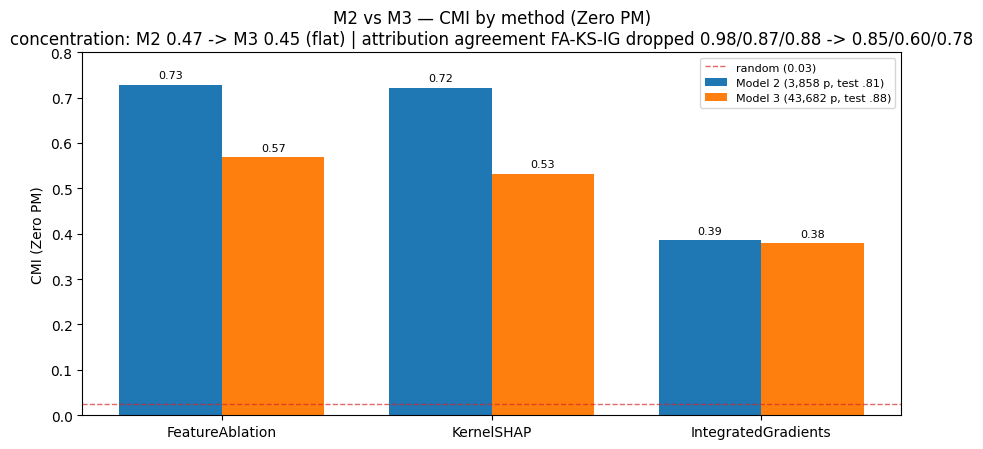

IG gap vs FA (Zero):  M2 = 0.728-0.386 = 0.342   M3 = 0.568-0.378 = 0.190  -> NARROWED
IG PES (Zero):  M2 = 0.56   M3 = 0.92


In [9]:
# M2 vs M3 comparison (Zero PM) — the first like-for-like
M2 = {"FeatureAblation": 0.728, "KernelSHAP": 0.721, "IntegratedGradients": 0.386}  # Model 2, Zero PM
M3 = {k: cmi[k]["zero"]["CMI"] for k in cmi}
methods = list(cmi); x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
b2 = ax.bar(x - w/2, [M2[m] for m in methods], w, label="Model 2 (3,858 p, test .81)", color="C0")
b3 = ax.bar(x + w/2, [M3[m] for m in methods], w, label="Model 3 (43,682 p, test .88)", color="C1")
for bars, d in [(b2, M2), (b3, M3)]:
    for bar, m in zip(bars, methods):
        ax.text(bar.get_x()+bar.get_width()/2, d[m]+0.01, f"{d[m]:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(random_cmi, color="C3", ls="--", lw=1, alpha=0.7, label=f"random ({random_cmi:.2f})")
ax.set_xticks(x); ax.set_xticklabels(methods); ax.set_ylabel("CMI (Zero PM)"); ax.set_ylim(0, 0.8)
ax.set_title("M2 vs M3 — CMI by method (Zero PM)\n"
             f"concentration: M2 0.47 -> M3 {conc['mean']:.2f} (flat) | attribution agreement FA-KS-IG dropped 0.98/0.87/0.88 -> 0.85/0.60/0.78")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_model3_cmi_vs_m2.png", dpi=150, bbox_inches="tight"); plt.show()

print("IG gap vs FA (Zero):  M2 = 0.728-0.386 = 0.342   M3 = %.3f-%.3f = %.3f  -> %s"
      % (M3["FeatureAblation"], M3["IntegratedGradients"],
         M3["FeatureAblation"]-M3["IntegratedGradients"],
         "NARROWED" if (M3['FeatureAblation']-M3['IntegratedGradients']) < 0.342 else "widened"))
print("IG PES (Zero):  M2 = 0.56   M3 = %.2f" % cmi["IntegratedGradients"]["zero"]["PES"])

### The Models 1–3 table, the decomposition, and the read

**Models 1–3 (Zero PM CMI unless noted):**

| Model | Params | Test acc | KS | FA | IG | Concentration | Overfit gap |
|---|---|---|---|---|---|---|---|
| 1 — linear *(anchor, freq-band space, no IG)* | ~6 | 0.70 | 0.612 | 0.648 | — | 0.24 | ~0.20 |
| **2 — shallow CNN** | 3,858 | 0.810 | 0.721 | 0.728 | 0.386 | 0.47 | +0.19 |
| **3 — medium CNN** | 43,682 | 0.880 | **0.533** | **0.568** | 0.378 | **0.45** | +0.12 |

*(Model 3 full row: FA 0.568/0.568/0.679, KS 0.533/0.533/0.591, IG 0.378/0.378/0.430 for SampleMean/Zero/Laplace; oracle 0.568, random 0.025.)*

**Sanity vs controls — passes.** Every real method (0.38–0.68) is far above random (0.025); the weakest,
IG (0.378), is ~15× the floor. FA(Zero)=oracle exactly, as always. Nothing near-zero.

**Concentration decomposition of the M2→M3 CMI drop (the key disentanglement).** FA/KS CMI dropped
markedly (FA 0.728→0.568, KS 0.721→0.533; ~0.16–0.19). The confound test: does that drop **track a
concentration drop**? **No — concentration is essentially flat (0.465 → 0.449, −0.02).** So the CMI
drop is **not** explained by the model becoming more diffuse. (Note the subtlety: the attribution
*mean profile* spread out M2→M3, but per-beat reliance stays concentrated — just on *different* regions
across beats — so per-sample concentration barely moves. Mean-profile spread ≠ concentration.)
Crucially, the **oracle (the CMI ceiling) itself dropped 0.728 → 0.568** while concentration held — so
the *maximum achievable* faithfulness fell, and that ceiling drop is **not** a diffuseness artifact.
Read: the M2→M3 CMI decline is a **genuine drop in achievable faithfulness**, not the concentration
confound — the medium CNN is genuinely harder to explain faithfully than the shallow one.

**THREAD #7 — cross-method agreement declining (first-class finding).** Attribution agreement fell
M2→M3 (0.98/0.87/0.88 → 0.85/0.60/0.78), and it is **not** subject to the concentration confound (it's
about method outputs, not model reliance). It points the **same way** as the CMI/ceiling result: the
deeper model is both **harder to explain faithfully** (lower oracle CMI) and one on which the methods
**agree less**. Two independent signatures — declining agreement *and* a falling faithfulness ceiling —
consistent with an explainability-ceiling forming as complexity rises. Tracked alongside CMI.

**THREAD — IG faithfulness: the gap NARROWED, opposite to the M2 worry.** On M2 we flagged IG far
behind (0.386 vs 0.728, gap 0.342). On M3 the **IG-vs-FA gap narrows to 0.190** — but not because IG
improved: **IG is flat (0.386 → 0.378)** while **FA/KS fell toward it**. And IG's **PES rose 0.56 →
0.92** — IG became *more consistent* across beats even as it diverged more from FA/KS in *where* it
points. So the forming pattern is **method convergence in faithfulness as complexity rises** (the
ceiling descending toward IG's roughly-constant level), **not** "IG keeps falling behind." Worth
watching which way M4/M5 push this.

**Honest read — two clean points, no trend declared.** M2 and M3 give the first like-for-like pair, and
the picture is coherent: as we step from shallow to medium CNN, **test accuracy rises (0.81→0.88) while
faithfulness falls (FA/KS CMI down ~0.16), and this is *not* a concentration artifact** — accompanied
by declining method agreement and IG converging upward-relative. That is exactly the shape the
explainability-ceiling hypothesis predicts. **But it is two points.** A better-generalising model being
harder to explain is a compelling direction, not a trend — Models 4 (deep, ~404k) and 5 (transformer)
are needed before we draw a line. We record M3 as the second clean point and hold interpretation.